In [13]:
# 01 - Visualisation du dataset

## Objectif
''' Explorer visuellement le dataset de pièces de fonderie afin de :
- comprendre la structure des données
- comparer les classes OK et Defective
- observer les différences visuelles
- analyser les histogrammes d’intensité '''

## Sortie attendue
''' Une première compréhension du comportement visuel des deux classes avant le prétraitement. '''

' Une première compréhension du comportement visuel des deux classes avant le prétraitement. '

In [2]:
# ==========================================
# 1. Import des bibliothèques
# ==========================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import random

%matplotlib inline

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["image.cmap"] = "gray"

In [3]:
# ==========================================
# 2. Définir les chemins du dataset
# ==========================================

DATASET_DIR = Path("../data/raw/casting_data")

train_ok_dir = DATASET_DIR / "train" / "ok_front"
train_def_dir = DATASET_DIR / "train" / "def_front"

test_ok_dir = DATASET_DIR / "test" / "ok_front"
test_def_dir = DATASET_DIR / "test" / "def_front"

print("Train OK      :", train_ok_dir)
print("Train Defect  :", train_def_dir)
print("Test OK       :", test_ok_dir)
print("Test Defect   :", test_def_dir)

Train OK      : ..\data\raw\casting_data\train\ok_front
Train Defect  : ..\data\raw\casting_data\train\def_front
Test OK       : ..\data\raw\casting_data\test\ok_front
Test Defect   : ..\data\raw\casting_data\test\def_front


In [4]:
# ==========================================
# 3. Lister les images
# ==========================================

def list_images(folder):
    extensions = ["*.jpg", "*.jpeg", "*.png", "*.bmp", "*.tif", "*.tiff"]
    files = []
    for ext in extensions:
        files.extend(folder.glob(ext))
    return sorted(files)

train_ok_images = list_images(train_ok_dir)
train_def_images = list_images(train_def_dir)
test_ok_images = list_images(test_ok_dir)
test_def_images = list_images(test_def_dir)

print(f"Train OK       : {len(train_ok_images)} images")
print(f"Train Defective: {len(train_def_images)} images")
print(f"Test OK        : {len(test_ok_images)} images")
print(f"Test Defective : {len(test_def_images)} images")

Train OK       : 2875 images
Train Defective: 3758 images
Test OK        : 262 images
Test Defective : 453 images


In [5]:
# ==========================================
# 4. Charger une image en grayscale
# ==========================================

def load_grayscale_image(image_path):
    img = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
    
    if img is None:
        raise ValueError(f"Impossible de lire l'image : {image_path}")
    
    return img

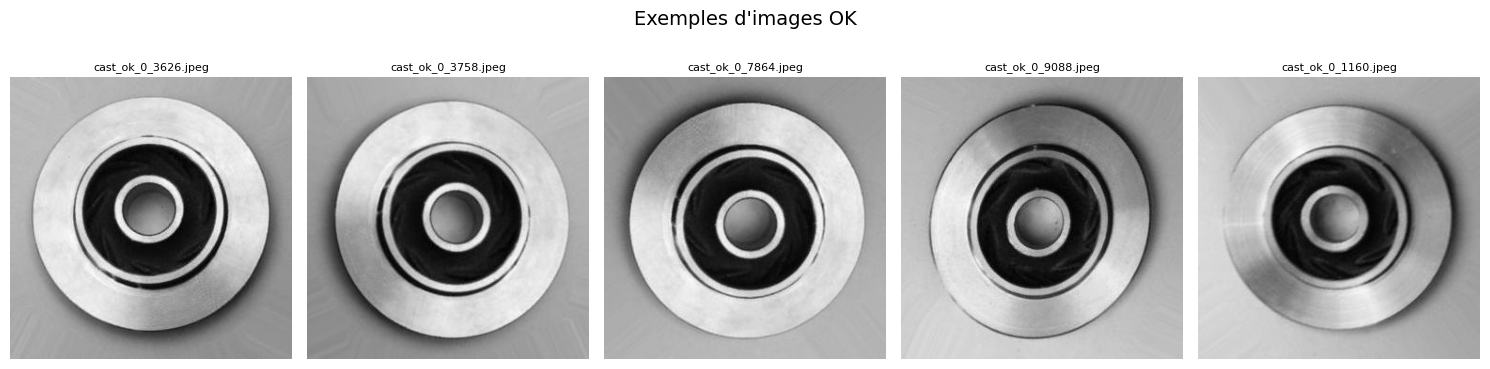

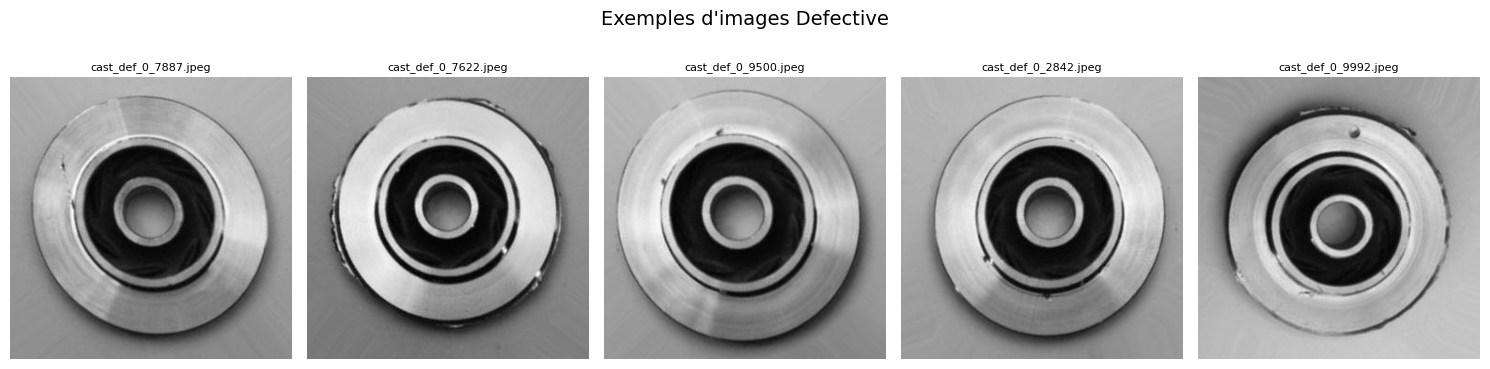

In [6]:
# ==========================================
# 5. Afficher quelques exemples
# ==========================================

def show_random_images(image_paths, title, n=5):
    selected_paths = random.sample(image_paths, min(n, len(image_paths)))
    
    fig, axes = plt.subplots(1, len(selected_paths), figsize=(15, 4))
    fig.suptitle(title, fontsize=14)
    
    if len(selected_paths) == 1:
        axes = [axes]
    
    for ax, path in zip(axes, selected_paths):
        img = load_grayscale_image(path)
        ax.imshow(img, cmap="gray")
        ax.set_title(path.name, fontsize=8)
        ax.axis("off")
    
    plt.tight_layout()
    plt.show()

show_random_images(train_ok_images, "Exemples d'images OK", n=5)
show_random_images(train_def_images, "Exemples d'images Defective", n=5)

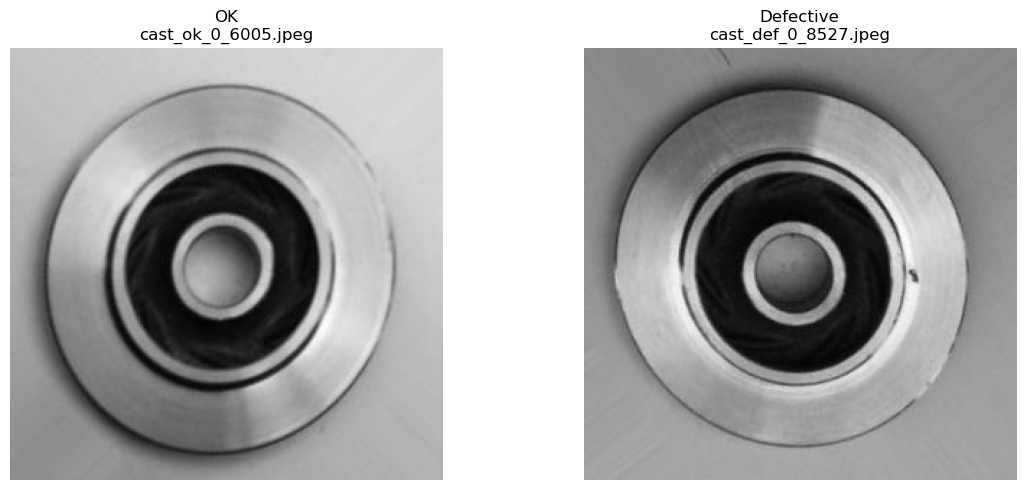

OK        -> shape: (300, 300) | min: 1 | max: 255 | mean: 150.44
Defective -> shape: (300, 300) | min: 0 | max: 255 | mean: 132.51


In [7]:
# ==========================================
# 6. Comparaison directe OK vs Defective
# ==========================================

ok_path = random.choice(train_ok_images)
def_path = random.choice(train_def_images)

ok_img = load_grayscale_image(ok_path)
def_img = load_grayscale_image(def_path)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(ok_img, cmap="gray")
axes[0].set_title(f"OK\n{ok_path.name}")
axes[0].axis("off")

axes[1].imshow(def_img, cmap="gray")
axes[1].set_title(f"Defective\n{def_path.name}")
axes[1].axis("off")

plt.tight_layout()
plt.show()

print("OK        -> shape:", ok_img.shape, "| min:", ok_img.min(), "| max:", ok_img.max(), "| mean:", round(ok_img.mean(), 2))
print("Defective -> shape:", def_img.shape, "| min:", def_img.min(), "| max:", def_img.max(), "| mean:", round(def_img.mean(), 2))

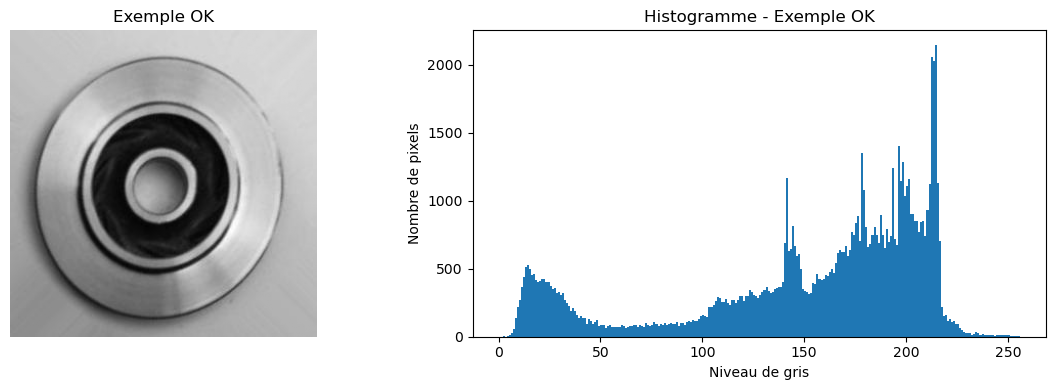

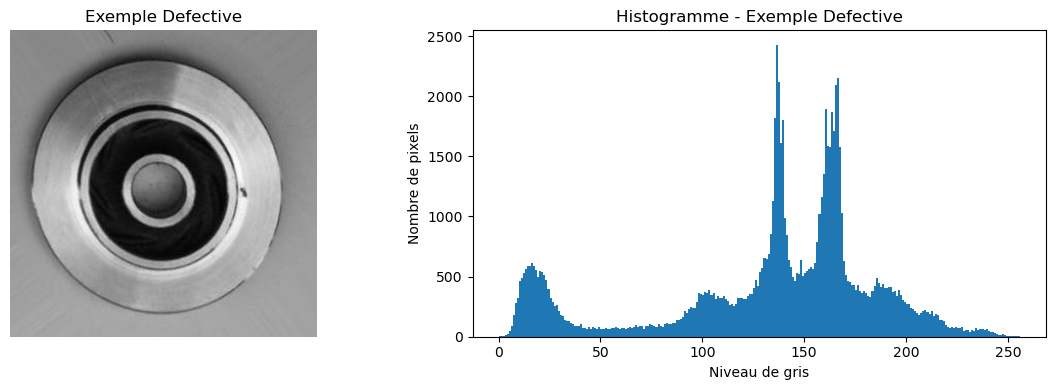

In [10]:
# ==========================================
# 7. Image + histogramme
# ==========================================

def plot_image_and_histogram(img, title="Image"):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    axes[0].imshow(img, cmap="gray")
    axes[0].set_title(title)
    axes[0].axis("off")
    
    axes[1].hist(img.ravel(), bins=256, range=(0, 256))
    axes[1].set_title(f"Histogramme - {title}")
    axes[1].set_xlabel("Niveau de gris")
    axes[1].set_ylabel("Nombre de pixels")
    
    plt.tight_layout()
    plt.show()

plot_image_and_histogram(ok_img, "Exemple OK")
plot_image_and_histogram(def_img, "Exemple Defective")

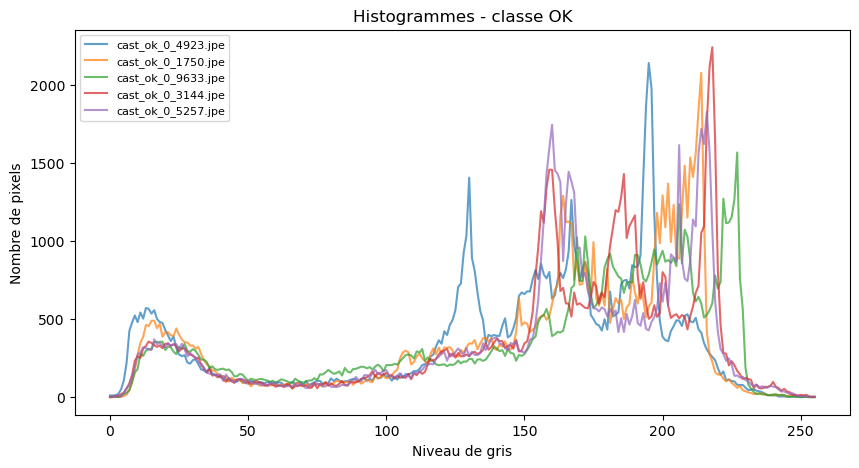

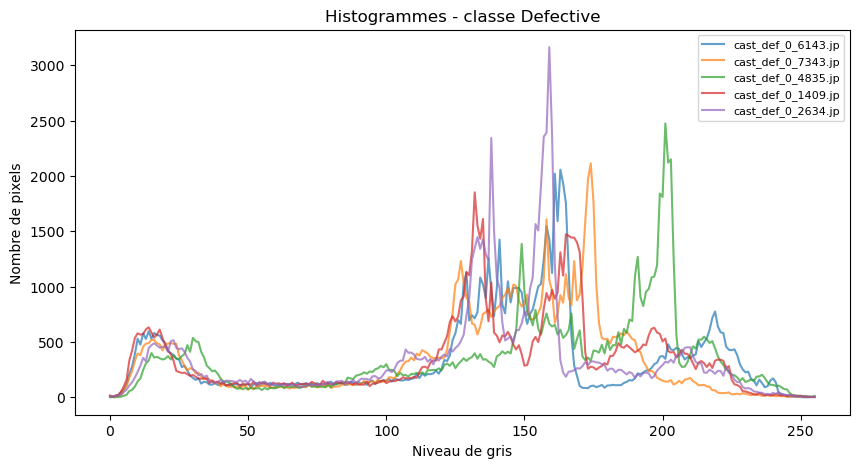

In [11]:
# ==========================================
# 8. Histogrammes de plusieurs images
# ==========================================

def plot_multiple_histograms(image_paths, class_name, n=5):
    selected_paths = random.sample(image_paths, min(n, len(image_paths)))
    
    plt.figure(figsize=(10, 5))
    
    for path in selected_paths:
        img = load_grayscale_image(path)
        hist, _ = np.histogram(img.ravel(), bins=256, range=(0, 256))
        plt.plot(hist, alpha=0.7, label=path.name[:18])
    
    plt.title(f"Histogrammes - classe {class_name}")
    plt.xlabel("Niveau de gris")
    plt.ylabel("Nombre de pixels")
    plt.legend(fontsize=8)
    plt.show()

plot_multiple_histograms(train_ok_images, "OK", n=5)
plot_multiple_histograms(train_def_images, "Defective", n=5)

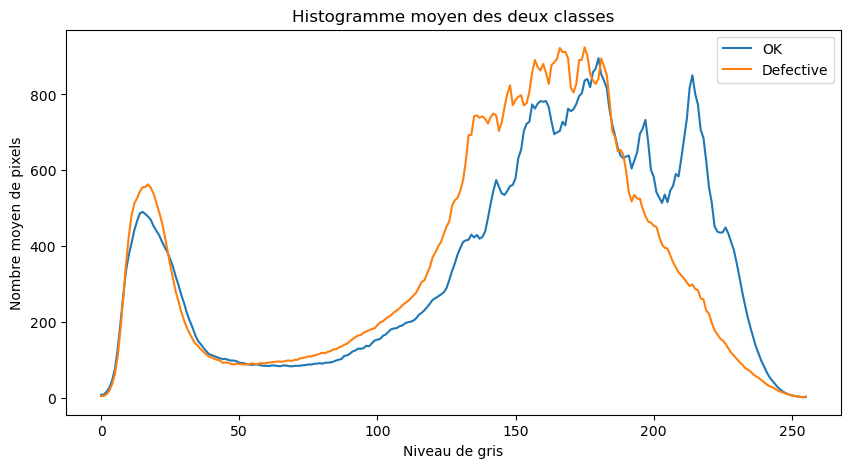

In [12]:
# ==========================================
# 9. Histogramme moyen par classe
# ==========================================

def compute_mean_histogram(image_paths, max_images=100):
    selected_paths = image_paths[:max_images]
    hist_sum = np.zeros(256, dtype=np.float64)
    
    for path in selected_paths:
        img = load_grayscale_image(path)
        hist, _ = np.histogram(img.ravel(), bins=256, range=(0, 256))
        hist_sum += hist
    
    return hist_sum / len(selected_paths)

mean_hist_ok = compute_mean_histogram(train_ok_images, max_images=100)
mean_hist_def = compute_mean_histogram(train_def_images, max_images=100)

plt.figure(figsize=(10, 5))
plt.plot(mean_hist_ok, label="OK")
plt.plot(mean_hist_def, label="Defective")
plt.title("Histogramme moyen des deux classes")
plt.xlabel("Niveau de gris")
plt.ylabel("Nombre moyen de pixels")
plt.legend()
plt.show()